# Projet 4 : Partie 1 - Identifiez les causes d'attrition au sein d'une ESN



# Etape 1 : Analyse exploratoire des fichiers de données

In [1]:
from pathlib import Path
import types
import dill


# ============================================================
# LOCALISATION AUTOMATIQUE DU PROJET
# ============================================================

CURRENT_DIR = Path.cwd().resolve()

candidats = [
    CURRENT_DIR,
    CURRENT_DIR / "Script_intermediaire",
    Path.home() / "Downloads" / "Projet 4" / "Script_intermediaire",
]

# Ajout des dossiers parents et de leurs éventuels sous-dossiers
for parent in CURRENT_DIR.parents:
    candidats.append(parent)

    candidats.append(parent / "Script_intermediaire")


SCRIPT_DIR = next(
    (
        chemin
        for chemin in candidats
        if chemin.is_dir()
        and chemin.name == "Script_intermediaire"
    ),
    None,
)


if SCRIPT_DIR is None:
    raise FileNotFoundError(
        "Impossible de localiser le dossier 'Script_intermediaire'.\n"
        f"Dossier courant détecté : {CURRENT_DIR}"
    )


SESSION_DIR = SCRIPT_DIR / "outputs"
SESSION_DIR.mkdir(parents=True, exist_ok=True)


# ============================================================
# OBJETS TECHNIQUES À NE PAS SAUVEGARDER
# ============================================================

NOMS_TECHNIQUES = {
    "In",
    "Out",
    "exit",
    "quit",
    "get_ipython",
    "open",
    "CURRENT_DIR",
    "SCRIPT_DIR",
    "SESSION_DIR",
    "NOMS_TECHNIQUES",
    "candidats",
    "parent",
    "chemin",
    "sauvegarder_session",
    "charger_session",
    "objets_restaures",
}


# ============================================================
# SAUVEGARDE AUTOMATIQUE
# ============================================================

def sauvegarder_session(etape):
    """
    Sauvegarde automatiquement tous les objets utilisateur
    sérialisables présents dans le notebook.

    Les modules, objets internes de Jupyter/VS Code et objets
    non sérialisables sont ignorés.
    """

    chemin_final = SESSION_DIR / f"session_etape{etape}.pkl"
    chemin_temporaire = SESSION_DIR / f"session_etape{etape}.tmp"

    objets_serialises = {}
    objets_ignores = {}

    for nom, objet in list(globals().items()):

        # Objets internes ou privés
        if nom.startswith("_"):
            continue

        # Infrastructure de sauvegarde
        if nom in NOMS_TECHNIQUES:
            continue

        # Objets techniques injectés par Data Wrangler
        if "DW_OUTPUT_FORMATTER" in nom:
            continue

        # Les modules seront réimportés normalement
        if isinstance(objet, types.ModuleType):
            continue

        try:
            # Chaque objet est sérialisé séparément.
            # Un objet défectueux ne bloque donc pas tous les autres.
            objets_serialises[nom] = dill.dumps(
                objet,
                recurse=True
            )

        except Exception as erreur:
            objets_ignores[nom] = (
                f"{type(erreur).__name__}: {erreur}"
            )

    contenu_session = {
        "version": 1,
        "etape": etape,
        "objets": objets_serialises,
    }

    # Écriture atomique : on écrit d'abord dans un fichier temporaire
    with open(chemin_temporaire, "wb") as fichier:
        dill.dump(contenu_session, fichier)

    chemin_temporaire.replace(chemin_final)

    print("=" * 65)
    print(f"Session de l'étape {etape} enregistrée")
    print(f"Fichier : {chemin_final}")
    print(f"Objets sauvegardés : {len(objets_serialises)}")
    print(f"Objets ignorés : {len(objets_ignores)}")

    if objets_ignores:
        print("\nObjets non sérialisables ignorés :")

        for nom, erreur in objets_ignores.items():
            print(f" - {nom} → {erreur}")

    print("=" * 65)

    return chemin_final


# ============================================================
# CHARGEMENT AUTOMATIQUE
# ============================================================

def charger_session(etape):
    """
    Recharge automatiquement tous les objets enregistrés
    à l'étape demandée, avec leurs noms d'origine.
    """

    chemin_session = SESSION_DIR / f"session_etape{etape}.pkl"

    if not chemin_session.exists():
        raise FileNotFoundError(
            f"Session introuvable : {chemin_session}\n"
            f"Exécute d'abord entièrement le notebook de l'étape {etape}."
        )

    with open(chemin_session, "rb") as fichier:
        contenu_session = dill.load(fichier)

    objets_serialises = contenu_session["objets"]

    objets_restaures = {}
    objets_non_restaures = {}

    for nom, objet_serialise in objets_serialises.items():

        try:
            objets_restaures[nom] = dill.loads(
                objet_serialise
            )

        except Exception as erreur:
            objets_non_restaures[nom] = (
                f"{type(erreur).__name__}: {erreur}"
            )

    globals().update(objets_restaures)

    print("=" * 65)
    print(f"Session de l'étape {etape} chargée")
    print(f"Fichier : {chemin_session}")
    print(f"Objets restaurés : {len(objets_restaures)}")
    print(f"Objets non restaurés : {len(objets_non_restaures)}")

    if objets_non_restaures:
        print("\nObjets impossibles à restaurer :")

        for nom, erreur in objets_non_restaures.items():
            print(f" - {nom} → {erreur}")

    print("=" * 65)

    return objets_restaures


print("Infrastructure de session initialisée")
print("Dossier des notebooks :", SCRIPT_DIR)
print("Dossier des sessions :", SESSION_DIR)

Infrastructure de session initialisée
Dossier des notebooks : /Users/thibaultdautheville/Downloads/Projet 4/Script_intermediaire
Dossier des sessions : /Users/thibaultdautheville/Downloads/Projet 4/Script_intermediaire/outputs


In [2]:
#Librairy


from pathlib import Path
import warnings

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import (
    OneHotEncoder,
    StandardScaler,
)

from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from xgboost import XGBClassifier

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
)

In [3]:
    

#base_dir = Path('/Users/thibaultdautheville/Library/Mobile Documents/com~apple~CloudDocs/MBA Data Science OC/Projet 4')


base_dir = Path(r"/Users/thibaultdautheville/Downloads/Projet 4")
files = {
    'eval': base_dir / 'extrait_eval.csv',
    'sirh': base_dir / 'extrait_sirh.csv',
    'sondage': base_dir / 'extrait_sondage.csv',
}

for name, path in files.items():
    if not path.exists():
        raise FileNotFoundError(f'Fichier introuvable : {path}')

# Chargement des trois jeux de données
(df_eval, df_sirh, df_sondage) = [pd.read_csv(files[name]) for name in ['eval', 'sirh', 'sondage']]

# Vérification rapide
print('Chargement terminé')
print('eval:', df_eval.shape)
print('sirh:', df_sirh.shape)
print('sondage:', df_sondage.shape)

Chargement terminé
eval: (1470, 10)
sirh: (1470, 12)
sondage: (1470, 12)


In [4]:
print('Aperçu des premières lignes')
df_eval.head()

print('\nTypes de colonnes')
df_eval.dtypes

print('\nStatistiques descriptives')
df_eval.describe(include='all').T

print('\nValeurs manquantes')
df_eval.isna().sum().sort_values(ascending=False).to_frame(name='nb_manquants')

print('\nNombre de valeurs uniques')
df_eval.nunique().sort_values(ascending=False).to_frame(name='nb_uniques')

print('\nDoublons')
print(df_eval.duplicated().sum())

df_eval.info()

Aperçu des premières lignes

Types de colonnes

Statistiques descriptives

Valeurs manquantes

Nombre de valeurs uniques

Doublons
0
<class 'pandas.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 10 columns):
 #   Column                                     Non-Null Count  Dtype
---  ------                                     --------------  -----
 0   satisfaction_employee_environnement        1470 non-null   int64
 1   note_evaluation_precedente                 1470 non-null   int64
 2   niveau_hierarchique_poste                  1470 non-null   int64
 3   satisfaction_employee_nature_travail       1470 non-null   int64
 4   satisfaction_employee_equipe               1470 non-null   int64
 5   satisfaction_employee_equilibre_pro_perso  1470 non-null   int64
 6   eval_number                                1470 non-null   str  
 7   note_evaluation_actuelle                   1470 non-null   int64
 8   heure_supplementaires                      1470 non-null   str  
 

Il y a le même nombre de ligne et presque le mêmes nombre de colonnes pour chaque fichiers

In [5]:
# Analyse descriptive des variables eval_number et satisfaction_employee_environnement

print('Variable: eval_number')
print('Type:', df_eval['eval_number'].dtype)
print('Nombre de valeurs uniques:', df_eval['eval_number'].nunique())


print(df_eval['eval_number'].describe())

print('\nVariable: satisfaction_employee_environnement')
print('Type:', df_eval['satisfaction_employee_environnement'].dtype)
print('Statistiques descriptives:')
print(df_eval['satisfaction_employee_environnement'].describe())
print('Fréquences:')
print(df_eval['satisfaction_employee_environnement'].value_counts().sort_index())

Variable: eval_number
Type: str
Nombre de valeurs uniques: 1470
count     1470
unique    1470
top        E_1
freq         1
Name: eval_number, dtype: object

Variable: satisfaction_employee_environnement
Type: int64
Statistiques descriptives:
count    1470.000000
mean        2.721769
std         1.093082
min         1.000000
25%         2.000000
50%         3.000000
75%         4.000000
max         4.000000
Name: satisfaction_employee_environnement, dtype: float64
Fréquences:
satisfaction_employee_environnement
1    284
2    287
3    453
4    446
Name: count, dtype: int64


La moyenne de satisfaction_employee_environnement est de 2,70 / 4
eval_number est l'identifiant de la personne

In [6]:
df_eval.head(10)

,satisfaction_employee_environnement,note_evaluation_precedente,niveau_hierarchique_poste,satisfaction_employee_nature_travail,satisfaction_employee_equipe,satisfaction_employee_equilibre_pro_perso,eval_number,note_evaluation_actuelle,heure_supplementaires,augementation_salaire_precedente
0,2,3,2,4,1,1,E_1,3,Oui,11 %
1,3,2,2,2,4,3,E_2,4,Non,23 %
2,4,2,1,3,2,3,E_4,3,Oui,15 %
3,4,3,1,3,3,3,E_5,3,Oui,11 %
4,1,3,1,2,4,3,E_7,3,Non,12 %
5,4,3,1,4,3,2,E_8,3,Non,13 %
6,3,4,1,1,1,2,E_10,4,Oui,20 %
7,4,3,1,3,2,3,E_11,4,Non,22 %
8,4,2,3,3,2,3,E_12,4,Non,21 %
9,3,3,2,3,2,2,E_13,3,Non,13 %


### Deuxieme dataset SIRH

In [7]:
# Analyse exploratoire du dataset df_sirh

print('Aperçu des premières lignes')
df_sirh.head()

print('\nTypes de colonnes')
df_sirh.dtypes

print('\nStatistiques descriptives')
df_sirh.describe(include='all').T

print('\nValeurs manquantes')
df_sirh.isna().sum().sort_values(ascending=False).to_frame(name='nb_manquants')

print('\nNombre de valeurs uniques')
df_sirh.nunique().sort_values(ascending=False).to_frame(name='nb_uniques')

print('\nDoublons')
print(df_sirh.duplicated().sum())

print('\nInformations générales')
df_sirh.info()

Aperçu des premières lignes

Types de colonnes

Statistiques descriptives

Valeurs manquantes

Nombre de valeurs uniques

Doublons
0

Informations générales
<class 'pandas.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 12 columns):
 #   Column                          Non-Null Count  Dtype
---  ------                          --------------  -----
 0   id_employee                     1470 non-null   int64
 1   age                             1470 non-null   int64
 2   genre                           1470 non-null   str  
 3   revenu_mensuel                  1470 non-null   int64
 4   statut_marital                  1470 non-null   str  
 5   departement                     1470 non-null   str  
 6   poste                           1470 non-null   str  
 7   nombre_experiences_precedentes  1470 non-null   int64
 8   nombre_heures_travailless       1470 non-null   int64
 9   annee_experience_totale         1470 non-null   int64
 10  annees_dans_l_entreprise        14

In [8]:
# Catégories des variables departement et poste

for col in ['departement', 'poste']:
    print(f'\n--- {col} ---')
    print(df_sirh[col].value_counts(dropna=False).to_string())


--- departement ---
departement
Consulting             961
Commercial             446
Ressources Humaines     63

--- poste ---
poste
Cadre Commercial           326
Assistant de Direction     292
Consultant                 259
Tech Lead                  145
Manager                    131
Senior Manager             102
Représentant Commercial     83
Directeur Technique         80
Ressources Humaines         52


Il y a trois département et 9 types de postes
    

In [9]:
# Statistiques simples des variables numériques (int64)

numeric_cols = df_sirh.select_dtypes(include=['int64']).columns.tolist()

print('Variables numériques :')
print(numeric_cols)

summary = df_sirh[numeric_cols].agg(['mean', 'min', 'max', 'median'])
summary

Variables numériques :
['id_employee', 'age', 'revenu_mensuel', 'nombre_experiences_precedentes', 'nombre_heures_travailless', 'annee_experience_totale', 'annees_dans_l_entreprise', 'annees_dans_le_poste_actuel']


,id_employee,age,revenu_mensuel,nombre_experiences_precedentes,nombre_heures_travailless,annee_experience_totale,annees_dans_l_entreprise,annees_dans_le_poste_actuel
mean,1024.865306,36.92381,6502.931293,2.693197,80.0,11.279592,7.008163,4.229252
min,1.000000,18.00000,1009.000000,0.000000,80.0,0.000000,0.000000,0.000000
max,2068.000000,60.00000,19999.000000,9.000000,80.0,40.000000,40.000000,18.000000
median,1020.500000,36.00000,4919.000000,2.000000,80.0,10.000000,5.000000,3.000000


l'âge moyen est de 37 ans, le revenu de 6500 avec une mdéianne à 4,9.
Tout le monde est à 80H / semaine


L'ancienneté moyenne dans l'entreprise est de 7 ans pour 11 en moyenne d'expérience

### Dataset sondage

In [10]:
# Analyse exploratoire du dataset df_sondage

print('Aperçu des premières lignes')
df_sondage.head()

print('\nTypes de colonnes')
df_sondage.dtypes

print('\nStatistiques descriptives')
df_sondage.describe(include='all').T

print('\nValeurs manquantes')
df_sondage.isna().sum().sort_values(ascending=False).to_frame(name='nb_manquants')

print('\nNombre de valeurs uniques')
df_sondage.nunique().sort_values(ascending=False).to_frame(name='nb_uniques')

print('\nDoublons')
print(df_sondage.duplicated().sum())

print('\nInformations générales')
df_sondage.info()

Aperçu des premières lignes

Types de colonnes

Statistiques descriptives

Valeurs manquantes

Nombre de valeurs uniques

Doublons
0

Informations générales
<class 'pandas.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 12 columns):
 #   Column                               Non-Null Count  Dtype
---  ------                               --------------  -----
 0   a_quitte_l_entreprise                1470 non-null   str  
 1   nombre_participation_pee             1470 non-null   int64
 2   nb_formations_suivies                1470 non-null   int64
 3   nombre_employee_sous_responsabilite  1470 non-null   int64
 4   code_sondage                         1470 non-null   int64
 5   distance_domicile_travail            1470 non-null   int64
 6   niveau_education                     1470 non-null   int64
 7   domaine_etude                        1470 non-null   str  
 8   ayant_enfants                        1470 non-null   str  
 9   frequence_deplacement                1

In [11]:
df_sondage

,a_quitte_l_entreprise,nombre_participation_pee,nb_formations_suivies,nombre_employee_sous_responsabilite,code_sondage,distance_domicile_travail,niveau_education,domaine_etude,ayant_enfants,frequence_deplacement,annees_depuis_la_derniere_promotion,annes_sous_responsable_actuel
0,Oui,0,0,1,1,1,2,Infra & Cloud,Y,Occasionnel,0,5
1,Non,1,3,1,2,8,1,Infra & Cloud,Y,Frequent,1,7
2,Oui,0,3,1,4,2,2,Autre,Y,Occasionnel,0,0
3,Non,0,3,1,5,3,4,Infra & Cloud,Y,Frequent,3,0
4,Non,1,3,1,7,2,1,Transformation Digitale,Y,Occasionnel,2,2
...,...,...,...,...,...,...,...,...,...,...,...,...
1465,Non,1,3,1,2061,23,2,Transformation Digitale,Y,Frequent,0,3
1466,Non,1,5,1,2062,6,1,Transformation Digitale,Y,Occasionnel,1,7
1467,Non,1,0,1,2064,4,3,Infra & Cloud,Y,Occasionnel,0,3
1468,Non,0,3,1,2065,2,3,Transformation Digitale,Y,Frequent,0,8


Création d'un dataset central DataFrameRH avec la clé commune id_employee à partir de eval_number

Méthode merge et inner

In [12]:
# Création du DataFrameRH à partir des trois datasets

# Création d'une clé commune id_employee à partir de eval_number

df_eval_rh = df_eval.copy()
df_eval_rh['id_employee'] = df_eval_rh['eval_number'].str.extract(r'(\d+)').astype(int)


df_sondage_rh = df_sondage.copy()
df_sondage_rh['id_employee'] = df_sondage_rh['code_sondage'].astype(int)

# Jointure des trois datasets
DataFrameRH = (
    df_eval_rh.merge(df_sirh, on='id_employee', how='inner')
              .merge(df_sondage_rh, on='id_employee', how='inner')
)

print('Taille du DataFrameRH :', DataFrameRH.shape)
DataFrameRH.head()

Taille du DataFrameRH : (1470, 34)


,satisfaction_employee_environnement,note_evaluation_precedente,niveau_hierarchique_poste,satisfaction_employee_nature_travail,satisfaction_employee_equipe,satisfaction_employee_equilibre_pro_perso,eval_number,note_evaluation_actuelle,heure_supplementaires,augementation_salaire_precedente,...,nb_formations_suivies,nombre_employee_sous_responsabilite,code_sondage,distance_domicile_travail,niveau_education,domaine_etude,ayant_enfants,frequence_deplacement,annees_depuis_la_derniere_promotion,annes_sous_responsable_actuel
0,2,3,2,4,1,1,E_1,3,Oui,11 %,...,0,1,1,1,2,Infra & Cloud,Y,Occasionnel,0,5
1,3,2,2,2,4,3,E_2,4,Non,23 %,...,3,1,2,8,1,Infra & Cloud,Y,Frequent,1,7
2,4,2,1,3,2,3,E_4,3,Oui,15 %,...,3,1,4,2,2,Autre,Y,Occasionnel,0,0
3,4,3,1,3,3,3,E_5,3,Oui,11 %,...,3,1,5,3,4,Infra & Cloud,Y,Frequent,3,0
4,1,3,1,2,4,3,E_7,3,Non,12 %,...,3,1,7,2,1,Transformation Digitale,Y,Occasionnel,2,2


Le dataset sondage donne des informations annuelles pour permettre aux RH d'améliorer le bien être des salariés

### Jointure

In [13]:
# Jointure dans un seul et unique dataset

# Création d'une clé commune id_employee à partir de eval_number
df_eval_rh = df_eval.copy()
df_eval_rh['id_employee'] = df_eval_rh['eval_number'].str.extract(r'(\d+)').astype(int)

# Harmonisation de la clé du dataset sondage
df_sondage_rh = df_sondage.copy()
df_sondage_rh['id_employee'] = df_sondage_rh['code_sondage'].astype(int)

# Jointure des trois datasets
DataFrameRH = (
    df_eval_rh.merge(df_sirh, on='id_employee', how='inner')
              .merge(df_sondage_rh, on='id_employee', how='inner')
)

print('Taille du DataFrameRH :', DataFrameRH.shape)

DataFrameRH.head()

Taille du DataFrameRH : (1470, 34)


,satisfaction_employee_environnement,note_evaluation_precedente,niveau_hierarchique_poste,satisfaction_employee_nature_travail,satisfaction_employee_equipe,satisfaction_employee_equilibre_pro_perso,eval_number,note_evaluation_actuelle,heure_supplementaires,augementation_salaire_precedente,...,nb_formations_suivies,nombre_employee_sous_responsabilite,code_sondage,distance_domicile_travail,niveau_education,domaine_etude,ayant_enfants,frequence_deplacement,annees_depuis_la_derniere_promotion,annes_sous_responsable_actuel
0,2,3,2,4,1,1,E_1,3,Oui,11 %,...,0,1,1,1,2,Infra & Cloud,Y,Occasionnel,0,5
1,3,2,2,2,4,3,E_2,4,Non,23 %,...,3,1,2,8,1,Infra & Cloud,Y,Frequent,1,7
2,4,2,1,3,2,3,E_4,3,Oui,15 %,...,3,1,4,2,2,Autre,Y,Occasionnel,0,0
3,4,3,1,3,3,3,E_5,3,Oui,11 %,...,3,1,5,3,4,Infra & Cloud,Y,Frequent,3,0
4,1,3,1,2,4,3,E_7,3,Non,12 %,...,3,1,7,2,1,Transformation Digitale,Y,Occasionnel,2,2


In [14]:
DataFrameRH.columns

Index(['satisfaction_employee_environnement', 'note_evaluation_precedente',
       'niveau_hierarchique_poste', 'satisfaction_employee_nature_travail',
       'satisfaction_employee_equipe',
       'satisfaction_employee_equilibre_pro_perso', 'eval_number',
       'note_evaluation_actuelle', 'heure_supplementaires',
       'augementation_salaire_precedente', 'id_employee', 'age', 'genre',
       'revenu_mensuel', 'statut_marital', 'departement', 'poste',
       'nombre_experiences_precedentes', 'nombre_heures_travailless',
       'annee_experience_totale', 'annees_dans_l_entreprise',
       'annees_dans_le_poste_actuel', 'a_quitte_l_entreprise',
       'nombre_participation_pee', 'nb_formations_suivies',
       'nombre_employee_sous_responsabilite', 'code_sondage',
       'distance_domicile_travail', 'niveau_education', 'domaine_etude',
       'ayant_enfants', 'frequence_deplacement',
       'annees_depuis_la_derniere_promotion', 'annes_sous_responsable_actuel'],
      dtype='str')

### Nettoyage 

certaines variables n'ont qu'une réponse unique ou sont maintenant 
inutiles, on les supprime.


In [15]:
# Tableau récapitulatif des variables du DataFrameRH

summary = []
for col in DataFrameRH.columns:
    dtype = str(DataFrameRH[col].dtype)
    values = DataFrameRH[col].dropna()
    sample = values.iloc[0] if len(values) > 0 else None
    if dtype.startswith('int') or dtype.startswith('float'):
        nature = 'Quantitative'
    else:
        nature = 'Qualitative'
    summary.append({
        'Variable': col,
        'Type_pandas': dtype,
        'Nature': nature,
        'Exemple': sample,
        'Nombre_de_valeurs_uniques': DataFrameRH[col].nunique()
    })

pd.DataFrame(summary)

,Variable,Type_pandas,Nature,Exemple,Nombre_de_valeurs_uniques
0,satisfaction_employee_environnement,int64,Quantitative,2,4
1,note_evaluation_precedente,int64,Quantitative,3,4
2,niveau_hierarchique_poste,int64,Quantitative,2,5
3,satisfaction_employee_nature_travail,int64,Quantitative,4,4
4,satisfaction_employee_equipe,int64,Quantitative,1,4
5,satisfaction_employee_equilibre_pro_perso,int64,Quantitative,1,4
6,eval_number,str,Qualitative,E_1,1470
7,note_evaluation_actuelle,int64,Quantitative,3,2
8,heure_supplementaires,str,Qualitative,Oui,2
9,augementation_salaire_precedente,str,Qualitative,11 %,15


Il est possible de déterminer rapidement les var qualitative et quantitive
Il faut observer le nombre de valeur unique.
Ici certaines variables sont de la forme numérique même si elles n'ont que 4 ou 5 modalité, il faut donc les transformer en catégorielle

In [16]:


cols_to_drop = ['code_sondage', 'eval_number', 'id_employee', 'ayant_enfants', 'nombre_heures_travailless']
DataFrameRH = DataFrameRH.drop(columns=cols_to_drop, errors='ignore')



### Analyse graphique var quantitative

Trois variables quantitative sont d'intérêt :
['satisfaction_employee_environnement', 'annees_dans_l_entreprise', 'revenu_mensuel']


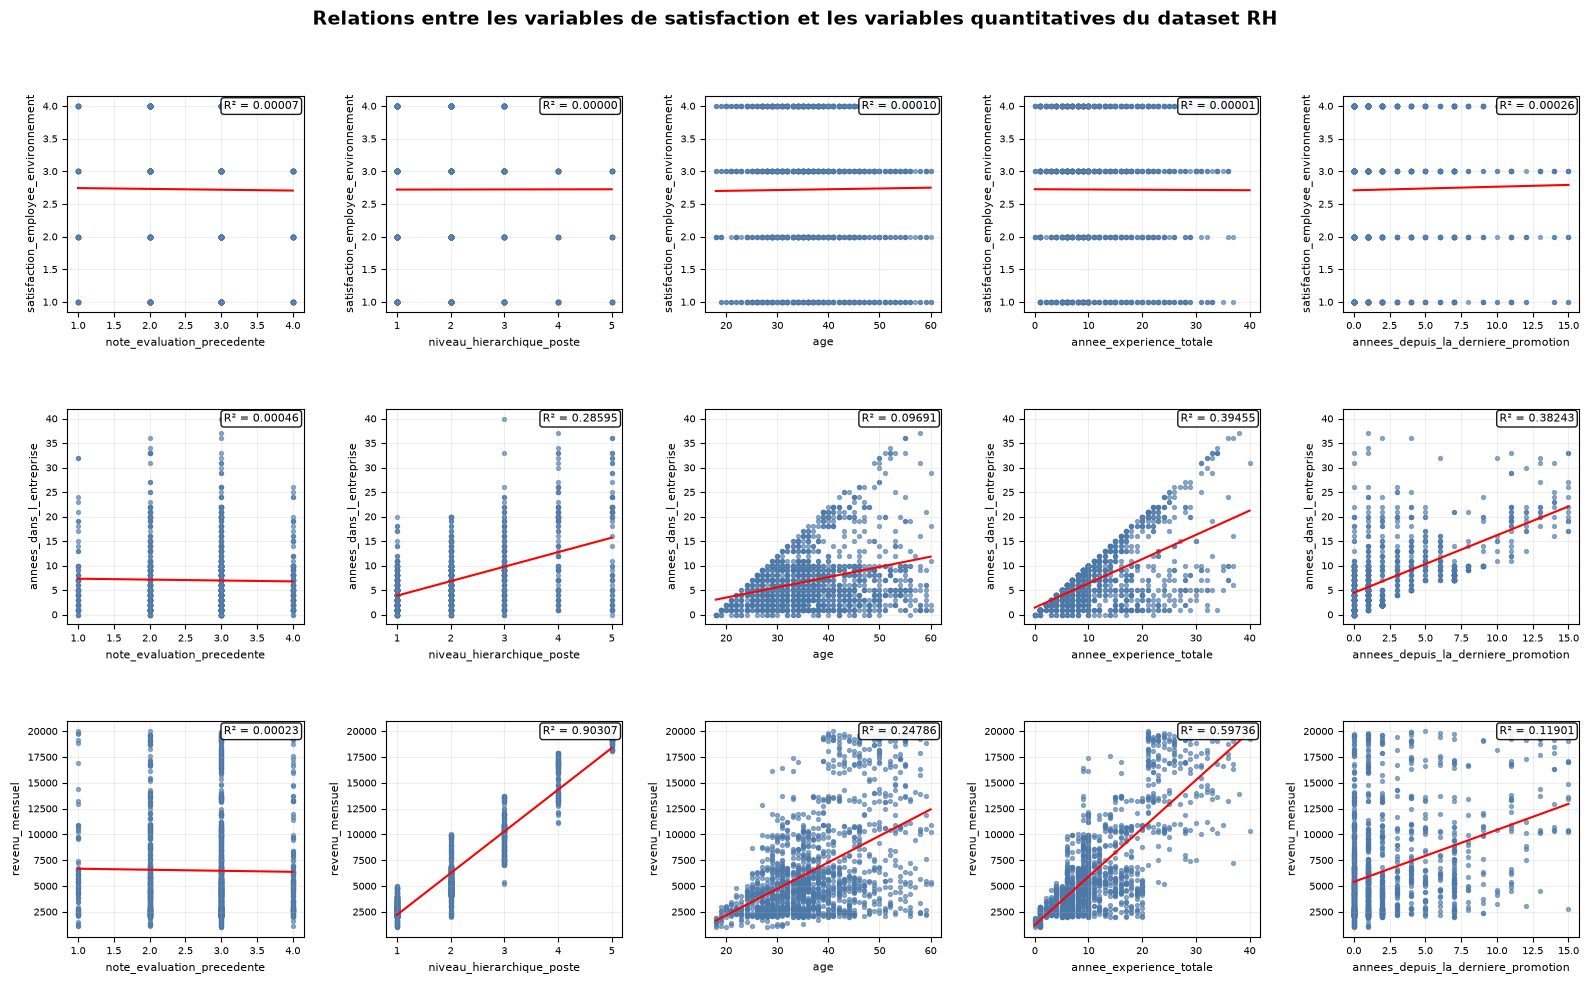

In [17]:


warnings.filterwarnings('ignore', category=np.exceptions.RankWarning)

targets = ['satisfaction_employee_environnement', 'annees_dans_l_entreprise', 
'revenu_mensuel']

quant_cols = [
    'note_evaluation_precedente',
    'niveau_hierarchique_poste',
    'age',
    'annee_experience_totale',
    'annees_depuis_la_derniere_promotion'
]

if len(targets) >= 1 and len(quant_cols) >= 1:
    n_targets = len(targets)
    n_cols = len(quant_cols)
    fig, axes = plt.subplots(n_targets, n_cols, figsize=(3.2 * n_cols, 3.2 * n_targets))

    for i, target in enumerate(targets):
        for j, col in enumerate(quant_cols):
            ax = axes[i, j]
            data = DataFrameRH[[target, col]].dropna()

            if data.shape[0] < 3:
                ax.set_visible(False)
                continue

            x = pd.to_numeric(data[col], errors='coerce')
            y = pd.to_numeric(data[target], errors='coerce')
            mask = x.notna() & y.notna()
            x = x[mask]
            y = y[mask]

            if len(x) < 3 or x.std() == 0:
                ax.set_visible(False)
                continue

            ax.scatter(x, y, s=8, alpha=0.6, color='#4C78A8')

            z = np.polyfit(x, y, 1)
            p = np.poly1d(z)
            x_sorted = np.sort(x)
            y_fit = p(x_sorted)
            ax.plot(x_sorted, y_fit, color='red', lw=1.5)

            y_pred = p(x)
            ss_res = np.sum((y - y_pred) ** 2)
            ss_tot = np.sum((y - np.mean(y)) ** 2)
            r2 = 1 - ss_res / ss_tot if ss_tot != 0 else 1.0

            ax.text(
                0.98, 0.98,
                f'R² = {r2:.5f}',
                transform=ax.transAxes,
                ha='right', va='top',
                fontsize=8,
                bbox=dict(boxstyle='round,pad=0.25', facecolor='white', alpha=0.9)
            )

            ax.set_xlabel(col, fontsize=8)
            ax.set_ylabel(target, fontsize=8)
            ax.tick_params(axis='both', labelsize=7)
            ax.grid(True, alpha=0.2)

    plt.tight_layout()
    fig.suptitle(
        'Relations entre les variables de satisfaction et les variables quantitatives du dataset RH',
        fontsize=14, fontweight='bold', y=1.02
    )
    fig.subplots_adjust(top=0.93, hspace=0.45, wspace=0.35)
    plt.show()
else:
    print('Pas assez de variables disponibles pour afficher le graphique.')

Commentaire graphique :
- Toutes les droites de régression sont quasi plates sur la ligne satisfaction_employee_environnement, sans exception

- satisfaction_employee_environnement est une forme de bandes horizontales strictes, la var ne varie pas assez finement pour qu'une droite ait un sens géométrique

- aucune des 5 variables (note d'évaluation, hiérarchie, âge, expérience, ancienneté depuis promotion) n'explique la satisfaction environnementale de façon linéaire 

- Pentes nettement positives et visuellement nettes sur age, annee_experience_totale, annees_dans_l_entreprise et revenu_mensuel : contrairement à la ligne satisfaction, ces variables montrent des nuages de points structurés en diagonale montante, pas des bandes plates

- la seule pente forte et non-tautologique digne d'intérêt est niveau_hierarchique_poste → revenu_mensuel, R²=0.90307 : un seul facteur explique 90% de la variance salariale


### Analyse graphique var qualitative

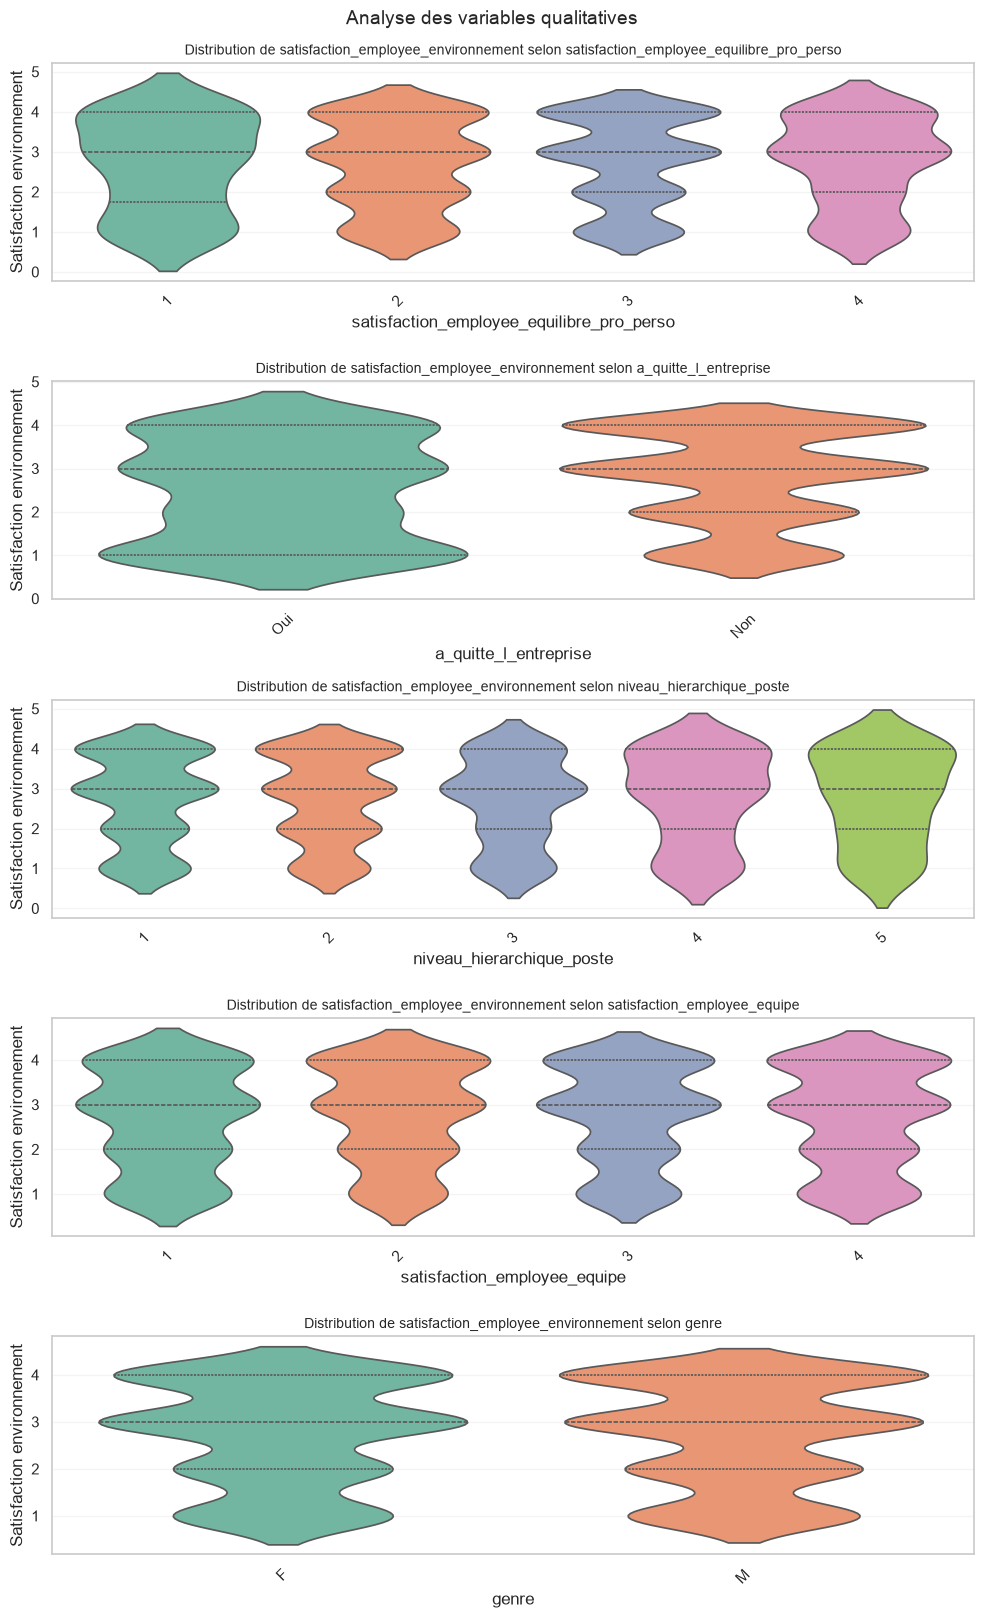

In [18]:

sns.set_theme(style='whitegrid')

target_var = 'satisfaction_employee_environnement'
qualitative_cols = [
    'satisfaction_employee_equilibre_pro_perso',
    'a_quitte_l_entreprise',
    'niveau_hierarchique_poste',
    'satisfaction_employee_equipe',
    'genre',
]

fig, axes = plt.subplots(len(qualitative_cols), 1, figsize=(10, 3.2 * len(qualitative_cols)))

for ax, col in zip(axes, qualitative_cols):
    plot_data = DataFrameRH[[col, target_var]].dropna()
    
    sns.violinplot(
    data=plot_data,
    x=col,
    y=target_var,
    hue=col,
    legend=False,
    ax=ax,
    inner='quartile',
    palette='Set2'
    )

    ax.set_title(f'Distribution de {target_var} selon {col}', fontsize=10)
    ax.tick_params(axis='x', rotation=45)
    ax.grid(True, axis='y', alpha=0.2)
    ax.set_xlabel(col)
    ax.set_ylabel('Satisfaction environnement')

plt.tight_layout()
plt.suptitle('Analyse des variables qualitatives', fontsize=14, y=1.01)
plt.show()

Commentaire résutlats

- la distribution du groupe "1" (a quitté) semble un peu plus tassée vers 1-3 que le groupe "0", suggère une satisfaction environnement légèrement plus faible chez les partants.
- Toutes les autres variables (satisfaction_employee_equilibre_pro_perso, niveau_hierarchique_poste, satisfaction_employee_equipe, genre) : aucune différence visuelle exploitable. 

### Statistiques descriptives 


In [19]:
target_vars = ['satisfaction_employee_environnement', 'annees_dans_l_entreprise', 'revenu_mensuel','a_quitte_l_entreprise']

summary_stats = []
for col in target_vars:
    ser = DataFrameRH[col]
    ser_num = pd.to_numeric(ser, errors='coerce')
    numeric_desc = ser_num.describe()
    summary_stats.append({
        'variable': col,
        'dtype': str(ser.dtype),
        'count': int(ser.notna().sum()),
        'n_unique': int(ser.nunique(dropna=True)),
        'mean': numeric_desc.get('mean', None),
        'std': numeric_desc.get('std', None),
        'min': numeric_desc.get('min', None),
        '25%': numeric_desc.get('25%', None),
        '50%': numeric_desc.get('50%', None),
        '75%': numeric_desc.get('75%', None),
        'max': numeric_desc.get('max', None),
    })

pd.DataFrame(summary_stats).set_index('variable')

,dtype,count,n_unique,mean,std,min,25%,50%,75%,max
variable,,,,,,,,,,
satisfaction_employee_environnement,int64,1470,4,2.721769,1.093082,1.0,2.0,3.0,4.0,4.0
annees_dans_l_entreprise,int64,1470,37,7.008163,6.126525,0.0,3.0,5.0,9.0,40.0
revenu_mensuel,int64,1470,1349,6502.931293,4707.956783,1009.0,2911.0,4919.0,8379.0,19999.0
a_quitte_l_entreprise,str,1470,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN


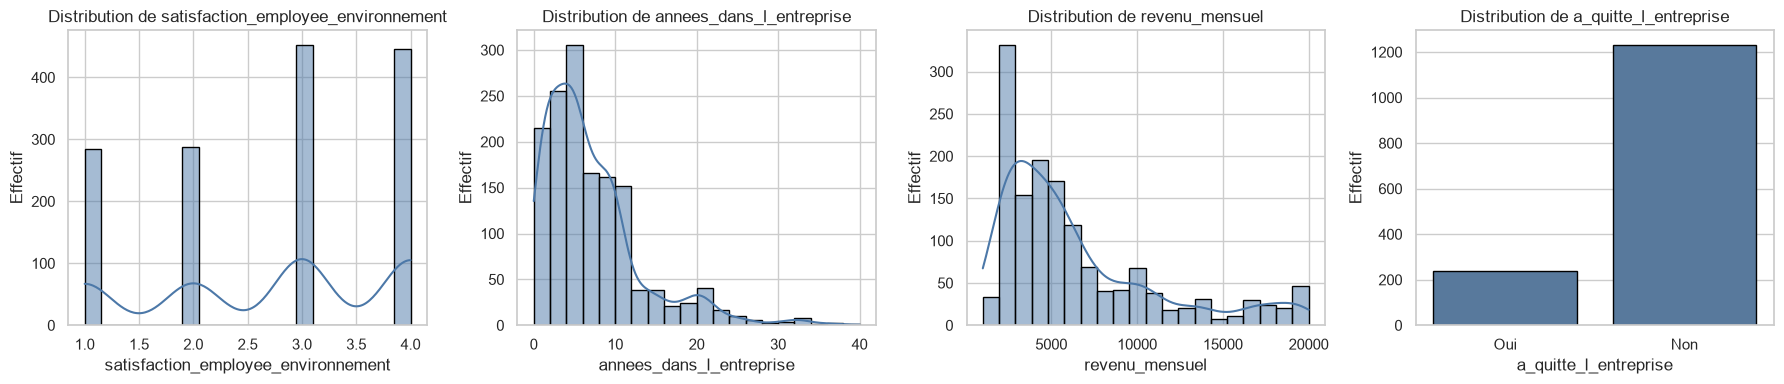

In [20]:
fig, axes = plt.subplots(1, len(target_vars), figsize=(18, 4))

for ax, col in zip(axes, target_vars):

    if col == "a_quitte_l_entreprise":
        sns.countplot(
            data=DataFrameRH,
            x=col,
            ax=ax,
            color="#4C78A8",
            edgecolor="black"
        )
        ax.set_title("Distribution de a_quitte_l_entreprise")
        ax.set_xlabel("a_quitte_l_entreprise")
        ax.set_ylabel("Effectif")

    else:
        serie = pd.to_numeric(DataFrameRH[col], errors="coerce")

        sns.histplot(
            serie.dropna(),
            kde=True,
            bins=20,
            color="#4C78A8",
            edgecolor="black",
            ax=ax
        )

        ax.set_title(f"Distribution de {col}")
        ax.set_xlabel(col)
        ax.set_ylabel("Effectif")

plt.tight_layout()
plt.show()

In [21]:
sauvegarder_session(1)

Session de l'étape 1 enregistrée
Fichier : /Users/thibaultdautheville/Downloads/Projet 4/Script_intermediaire/outputs/session_etape1.pkl
Objets sauvegardés : 59
Objets ignorés : 0


PosixPath('/Users/thibaultdautheville/Downloads/Projet 4/Script_intermediaire/outputs/session_etape1.pkl')